In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Data Cleaning**

### **Extract data from customer info sheet in messy excel**

In [2]:
folder = 'dataset'
file_path = f"{folder}/Bank_Churn_Messy.xlsx"

In [3]:
customer_df = pd.read_excel(file_path, sheet_name=0)
customer_df = pd.DataFrame(customer_df)

In [4]:
customer_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [5]:
len(customer_df)

10001

### **CustomerId type checking**

In [6]:
customer_df['CustomerId'].dtype

dtype('int64')

In [7]:
customer_df['CustomerId'] = customer_df['CustomerId'].astype('string')

In [8]:
customer_df['CustomerId'].dtype

string[python]

### **Extract data from account info sheet in messy excel**

In [9]:
account_df = pd.read_excel(file_path, sheet_name=1)
account_df = pd.DataFrame(account_df)

In [10]:
account_df.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


In [11]:
len(account_df)

10002

### **CustomerId type checking**

In [12]:
account_df['CustomerId'].dtype

dtype('int64')

In [13]:
account_df['CustomerId'] = account_df['CustomerId'].astype('string')

In [14]:
account_df['CustomerId'].dtype

string[python]

### **Merge info from customer and account**

In [15]:
bank_customer_df = account_df.merge(customer_df, how='left', on='CustomerId')
bank_customer_df.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure_x,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,Tenure_y,EstimatedSalary
0,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,2,€101348.88
2,15647311,€83807.86,1,Yes,1,Yes,0,Hill,608,Spain,Female,41.0,1,€112542.58
3,15619304,€159660.8,3,No,8,No,1,Onio,502,French,Female,42.0,8,€113931.57
4,15701354,€0.0,2,No,1,No,0,Boni,699,FRA,Female,39.0,1,€93826.63


In [16]:
len(bank_customer_df)

10004

In [17]:
bank_customer_df[bank_customer_df.duplicated(keep=False)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure_x,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,Tenure_y,EstimatedSalary
0,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,2,€101348.88
10000,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78
10001,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78
10002,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78
10003,15628319,€130142.79,1,No,4,No,0,Walker,792,French,Female,28.0,4,€38190.78


### **Dropping duplicated rows and columns**

In [18]:
bank_customer_df = bank_customer_df.drop_duplicates()

In [19]:
bank_customer_df[bank_customer_df.duplicated(keep=False)]

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure_x,IsActiveMember,Exited,Surname,CreditScore,Geography,Gender,Age,Tenure_y,EstimatedSalary


In [20]:
bank_customer_df = bank_customer_df.rename(columns={'Tenure_x': 'Tenure'})

In [21]:
bank_customer_df = bank_customer_df.drop(columns='Tenure_y')

In [22]:
bank_customer_df.columns

Index(['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure',
       'IsActiveMember', 'Exited', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'EstimatedSalary'],
      dtype='object')

### **Checking column dtypes**

In [23]:
bank_customer_df.dtypes

CustomerId         string[python]
Balance                    object
NumOfProducts               int64
HasCrCard                  object
Tenure                      int64
IsActiveMember             object
Exited                      int64
Surname                    object
CreditScore                 int64
Geography                  object
Gender                     object
Age                       float64
EstimatedSalary            object
dtype: object

In [24]:
bank_customer_df.columns = bank_customer_df.columns.str.strip().str.replace(" ", "_").str.lower()

In [25]:
bank_customer_df.columns

Index(['customerid', 'balance', 'numofproducts', 'hascrcard', 'tenure',
       'isactivemember', 'exited', 'surname', 'creditscore', 'geography',
       'gender', 'age', 'estimatedsalary'],
      dtype='object')

In [26]:
bank_customer_df.head()

,customerid,balance,numofproducts,hascrcard,tenure,isactivemember,exited,surname,creditscore,geography,gender,age,estimatedsalary
0,15634602,€0.0,1,Yes,2,Yes,1,Hargrave,619,FRA,Female,42.0,€101348.88
2,15647311,€83807.86,1,Yes,1,Yes,0,Hill,608,Spain,Female,41.0,€112542.58
3,15619304,€159660.8,3,No,8,No,1,Onio,502,French,Female,42.0,€113931.57
4,15701354,€0.0,2,No,1,No,0,Boni,699,FRA,Female,39.0,€93826.63
5,15737888,€125510.82,1,Yes,2,Yes,0,Mitchell,850,Spain,Female,43.0,€79084.1


#### **Changing dtypes of columns to appropriate ones**

In [27]:
bank_customer_df['hascrcard'].unique()

array(['Yes', 'No'], dtype=object)

In [28]:
bank_customer_df['isactivemember'].unique()

array(['Yes', 'No'], dtype=object)

In [29]:
bank_customer_df[['hascrcard', 'isactivemember']] = bank_customer_df[['hascrcard', 'isactivemember']].astype('string')

In [30]:
bank_customer_df[['hascrcard', 'isactivemember']] = bank_customer_df[['hascrcard', 'isactivemember']].replace({'Yes': '1', 'No': '0'})

In [31]:
bank_customer_df[['hascrcard', 'isactivemember']] = bank_customer_df[['hascrcard', 'isactivemember']].astype(int)

In [32]:
bank_customer_df[['hascrcard', 'isactivemember']].dtypes

hascrcard         int64
isactivemember    int64
dtype: object

In [33]:
bank_customer_df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [34]:
bank_customer_df['geography'].unique()

array(['FRA', 'Spain', 'French', 'France', 'Germany'], dtype=object)

In [35]:
bank_customer_df[['gender', 'geography']] = bank_customer_df[['gender', 'geography']].astype('string')

In [36]:
bank_customer_df['gender'] = bank_customer_df['gender'].str.strip().str.lower()

In [37]:
bank_customer_df['geography'] = bank_customer_df['geography'].str.strip().str.lower()

In [38]:
bank_customer_df['geography'] = bank_customer_df['geography'].replace(['fra', 'french'], 'france')

In [39]:
bank_customer_df['geography'].unique()

<StringArray>
['france', 'spain', 'germany']
Length: 3, dtype: string

In [40]:
bank_customer_df[['balance', 'estimatedsalary']] = bank_customer_df[['balance', 'estimatedsalary']].astype('string')

In [41]:
bank_customer_df[['balance', 'estimatedsalary']].dtypes

balance            string[python]
estimatedsalary    string[python]
dtype: object

In [42]:
bank_customer_df[['balance', 'estimatedsalary']] = bank_customer_df[['balance', 'estimatedsalary']].replace(r'[€,]', '', regex=True)

In [43]:
bank_customer_df[['balance', 'estimatedsalary']] = bank_customer_df[['balance', 'estimatedsalary']].astype(float)

#### **Missing values check**

In [44]:
len(bank_customer_df)

10000

In [45]:
bank_customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerid       10000 non-null  string 
 1   balance          10000 non-null  float64
 2   numofproducts    10000 non-null  int64  
 3   hascrcard        10000 non-null  int64  
 4   tenure           10000 non-null  int64  
 5   isactivemember   10000 non-null  int64  
 6   exited           10000 non-null  int64  
 7   surname          9997 non-null   object 
 8   creditscore      10000 non-null  int64  
 9   geography        10000 non-null  string 
 10  gender           10000 non-null  string 
 11  age              9997 non-null   float64
 12  estimatedsalary  10000 non-null  float64
dtypes: float64(3), int64(6), object(1), string(3)
memory usage: 1.1+ MB


In [46]:
bank_customer_df[bank_customer_df['age'].isna()]

,customerid,balance,numofproducts,hascrcard,tenure,isactivemember,exited,surname,creditscore,geography,gender,age,estimatedsalary
29,15728693,141349.43,1,1,3,1,0,NaN,574,germany,female,NaN,-999999.0
122,15580203,120193.42,1,0,6,0,0,NaN,674,spain,male,NaN,-999999.0
9390,15756954,0.00,1,1,2,1,0,NaN,538,france,female,NaN,-999999.0


In [47]:
bank_customer_df = bank_customer_df.dropna(subset=['balance', 'estimatedsalary', 'age', 'creditscore'])

In [48]:
bank_customer_df['age'] = bank_customer_df['age'].astype(int)

### **Dropping PII columns**

In [49]:
customerid_col = bank_customer_df['customerid']
surname_col = bank_customer_df['surname']

In [50]:
bank_customer_df = bank_customer_df.drop(columns=["customerid", "surname"])

In [51]:
bank_customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 10000
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   balance          9997 non-null   float64
 1   numofproducts    9997 non-null   int64  
 2   hascrcard        9997 non-null   int64  
 3   tenure           9997 non-null   int64  
 4   isactivemember   9997 non-null   int64  
 5   exited           9997 non-null   int64  
 6   creditscore      9997 non-null   int64  
 7   geography        9997 non-null   string 
 8   gender           9997 non-null   string 
 9   age              9997 non-null   int64  
 10  estimatedsalary  9997 non-null   float64
dtypes: float64(2), int64(7), string(2)
memory usage: 937.2 KB


In [52]:
bank_customer_df.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,76482.679807,1.530359,0.515055,5.013204,0.515055,0.203761,650.545364,38.922077,100092.222656
std,62397.174721,0.581669,0.499798,2.892364,0.499798,0.402814,96.657932,10.489072,57518.775702
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,11.580000
25%,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,584.000000,32.000000,50974.570000
50%,97188.620000,1.000000,1.000000,5.000000,1.000000,0.000000,652.000000,37.000000,100236.020000
75%,127642.440000,2.000000,1.000000,7.000000,1.000000,0.000000,718.000000,44.000000,149399.700000
max,250898.090000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,92.000000,199992.480000


There are 36% no saving customers and saving customers' balance behavior is stable. Need to study the difference between **no** saving and saving customers. While most customers use only 1 to 2 products, few customers use more than 2 products. Having Credit Card is directly related with Active Status. To increase customers' engagement, we should provide credit card plan. 55% of users have at least 5 years usage of bank service and thus most are long term customers, and longest term is 10 years old customers. New customers like 0 and oldest customers like 10 are quite few. 20% of customers are churners so we need to explore why they churn. 6% of customers have worst credit score, with below 500. But, 25% of them have high income and saving. We can approve suitable low risk loan using strict policies to prevent customers' churning. Our target customers' age is around 32 to 44, expanded range is 45 to 60. 74% of customers' salary is around 50k to 200k. 14% of customers are around 20k to 50k. Below 20k is 10% customers. 50% of customers are from france, 25% of customers from germany, and remaining 25% are from spain. Majority of customers are from france. 55% of customers are male and 45% are female. 

In [53]:
bank_customer_df['geography'].value_counts()

geography
france     5013
germany    2508
spain      2476
Name: count, dtype: Int64

In [54]:
bank_customer_df['gender'].value_counts()

gender
male      5456
female    4541
Name: count, dtype: Int64

In [55]:
bank_customer_df['balance'].std() / bank_customer_df['balance'].mean()

np.float64(0.8158340539164396)

<Axes: xlabel='balance', ylabel='Count'>

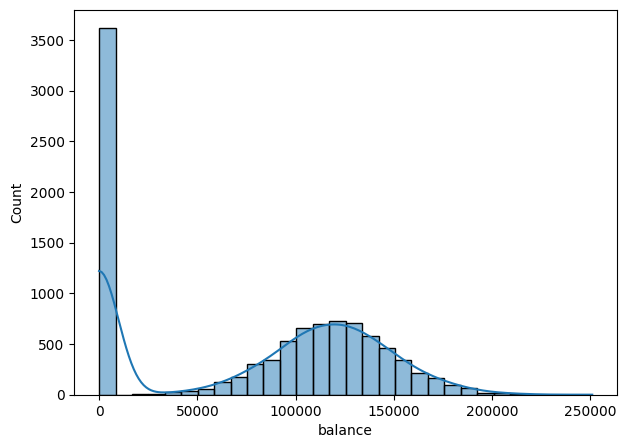

In [56]:
plt.figure(figsize=(7, 5))
sns.histplot(data=bank_customer_df, x='balance', bins=30, kde=True)

In [57]:
# bank_customer_df[bank_customer_df['balance']==0].describe()

In [58]:
bank_customer_df['numofproducts'].std() / bank_customer_df['numofproducts'].mean()

np.float64(0.380086668911186)

In [59]:
bank_customer_df['numofproducts'].value_counts(normalize=True)

numofproducts
1    0.508252
2    0.459138
3    0.026608
4    0.006002
Name: proportion, dtype: float64

In [60]:
pd.crosstab(bank_customer_df['hascrcard'], bank_customer_df['isactivemember'], rownames=['Has Credit Card'], colnames=['Active'])

Active,0,1
Has Credit Card,,
0,4848,0
1,0,5149


In [61]:
pd.crosstab(bank_customer_df['hascrcard'], bank_customer_df['exited'], rownames=['Has Credit Card'], colnames=['Churn Status'])

Churn Status,0,1
Has Credit Card,,
0,3546,1302
1,4414,735


In [62]:
print(1302 / (1302 + 3546))
print('\n')
print(735 / (735 + 4414))

0.2685643564356436


0.1427461643037483


In [63]:
bank_customer_df['creditscore'].std() / bank_customer_df['creditscore'].mean()

np.float64(0.148579848779716)

In [64]:
bank_customer_df[bank_customer_df['creditscore'] < 500]

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,geography,gender,age,estimatedsalary
8,115046.74,4,0,4,0,1,376,germany,female,29,119346.88
12,0.00,2,0,3,0,0,497,spain,male,24,76390.01
13,0.00,2,0,10,0,0,476,france,female,34,26260.98
30,59697.17,2,1,0,1,0,411,france,male,29,53483.21
36,134264.04,1,0,0,0,1,475,france,female,45,27822.99
...,...,...,...,...,...,...,...,...,...,...,...
9915,102723.35,2,0,1,0,0,496,france,female,34,180844.81
9931,166776.60,2,1,9,1,0,425,germany,male,40,172646.88
9965,117593.48,2,0,5,0,0,479,france,male,34,113308.29
9967,125920.98,1,1,4,1,0,479,spain,male,35,20393.44


In [65]:
bank_customer_df[(bank_customer_df['balance'] >= 100000) &
                 (bank_customer_df['estimatedsalary'] >= 100000) &
                 (bank_customer_df['creditscore'] < 500)]

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,geography,gender,age,estimatedsalary
8,115046.74,4,0,4,0,1,376,germany,female,29,119346.88
37,145260.23,1,1,3,1,0,490,spain,male,31,114066.77
42,122522.32,1,0,8,0,1,465,france,female,51,181297.65
126,152603.45,1,0,9,0,1,432,france,male,42,110265.24
171,130114.39,1,0,4,0,0,484,france,female,29,164017.89
...,...,...,...,...,...,...,...,...,...,...,...
9880,118356.89,2,0,9,0,1,486,germany,male,62,168034.83
9909,170295.04,2,0,9,0,0,492,germany,male,45,164741.81
9915,102723.35,2,0,1,0,0,496,france,female,34,180844.81
9931,166776.60,2,1,9,1,0,425,germany,male,40,172646.88


In [66]:
bank_customer_df['tenure'].std() / bank_customer_df['tenure'].mean()

np.float64(0.5769492835224079)

In [67]:
bank_customer_df['tenure'].value_counts()

tenure
2     1047
1     1035
7     1028
8     1025
5     1012
3     1008
4      989
9      984
6      966
10     490
0      413
Name: count, dtype: int64

In [68]:
bank_customer_df['geography'].value_counts()

geography
france     5013
germany    2508
spain      2476
Name: count, dtype: Int64

In [69]:
bank_customer_df['gender'].value_counts()

gender
male      5456
female    4541
Name: count, dtype: Int64

In [70]:
bank_customer_df[bank_customer_df['tenure'] >= 5].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,5505.000000,5505.000000,5505.000000,5505.000000,5505.000000,5505.000000,5505.000000,5505.000000,5505.000000
mean,75986.220710,1.534968,0.504814,7.267575,0.504814,0.198547,650.120981,38.883560,100670.256060
std,62762.370758,0.581872,0.500022,1.594348,0.500022,0.398942,96.864099,10.491538,57264.852032
min,0.000000,1.000000,0.000000,5.000000,0.000000,0.000000,350.000000,18.000000,90.070000
25%,0.000000,1.000000,0.000000,6.000000,0.000000,0.000000,585.000000,32.000000,51695.410000
50%,96951.210000,1.000000,1.000000,7.000000,1.000000,0.000000,651.000000,37.000000,100809.990000
75%,127758.090000,2.000000,1.000000,9.000000,1.000000,0.000000,718.000000,44.000000,149614.810000
max,222267.630000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,88.000000,199970.740000


In [71]:
bank_customer_df['age_group'] = pd.cut(bank_customer_df['age'], bins=[17, 20, 23, 31, 44, 60, 100], labels=['18-20', '21-23', '24-31', '32-44', '45-60', 'above 60'], right=True)

In [72]:
bank_customer_df['age_group'].value_counts()

age_group
32-44       5285
24-31       2047
45-60       1876
above 60     464
21-23        236
18-20         89
Name: count, dtype: int64

In [73]:
bank_customer_df[bank_customer_df['balance'] == 0]['age_group'].value_counts()

age_group
32-44       1935
24-31        787
45-60        600
above 60     167
21-23         91
18-20         36
Name: count, dtype: int64

In [74]:
print(28 / 67)
print(91 / 236)
print(167 / 464)
print(600 / 1876)
print(787 / 2047)
print(1935 / 5285)

0.417910447761194
0.3855932203389831
0.3599137931034483
0.31982942430703626
0.38446507083536885
0.3661305581835383


In [75]:
potential_active_customers = bank_customer_df[(bank_customer_df['hascrcard'] == 0) &
                 (bank_customer_df['exited'] == 0) &
                 (bank_customer_df['creditscore'] >= 700) &
                 (bank_customer_df['balance'] >= 100000) &
                 (bank_customer_df['estimatedsalary'] >= 100000)
                 ]

In [76]:
potential_active_customers.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,243.000000,243.000000,243.0,243.000000,243.0,243.0,243.000000,243.000000,243.000000
mean,130852.710576,1.349794,0.0,5.045267,0.0,0.0,760.777778,36.094650,151929.929630
std,20663.477546,0.486459,0.0,2.818550,0.0,0.0,45.218569,7.638209,29394.290828
min,100054.770000,1.000000,0.0,0.000000,0.0,0.0,700.000000,18.000000,100137.700000
25%,115011.695000,1.000000,0.0,3.000000,0.0,0.0,722.000000,31.000000,125683.170000
50%,126875.620000,1.000000,0.0,5.000000,0.0,0.0,756.000000,36.000000,152039.670000
75%,144389.910000,2.000000,0.0,7.000000,0.0,0.0,788.000000,41.000000,177038.145000
max,191775.650000,3.000000,0.0,10.000000,0.0,0.0,850.000000,68.000000,199484.960000


In [77]:
pd.crosstab(potential_active_customers['geography'], potential_active_customers['gender'], rownames=['Geography'], colnames=['Gender'])

Gender,female,male
Geography,,
france,42,74
germany,50,37
spain,17,23


In [78]:
bank_customer_df['estimatedsalary'].std() / bank_customer_df['estimatedsalary'].mean()

np.float64(0.5746577923438918)

In [79]:
bank_customer_df[bank_customer_df['estimatedsalary'] <= 50000].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,2453.000000,2453.000000,2453.000000,2453.000000,2453.000000,2453.000000,2453.000000,2453.000000,2453.000000
mean,75287.603502,1.516103,0.518549,4.978394,0.518549,0.199348,652.673869,38.872401,24926.066066
std,62669.588639,0.569985,0.499758,2.892152,0.499758,0.399591,95.610682,10.710735,14571.631954
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,395.000000,18.000000,11.580000
25%,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,586.000000,31.000000,12266.060000
50%,96471.200000,1.000000,1.000000,5.000000,1.000000,0.000000,652.000000,37.000000,25183.010000
75%,127849.380000,2.000000,1.000000,7.000000,1.000000,0.000000,719.000000,44.000000,37240.110000
max,206663.750000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,92.000000,49978.670000


In [80]:
bank_customer_df[bank_customer_df['estimatedsalary'] <= 20000].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,71806.964625,1.529412,0.522312,4.997972,0.522312,0.200811,649.282961,38.641988,9820.001085
std,63053.008010,0.580256,0.499755,2.864450,0.499755,0.400811,98.407100,10.370723,5815.136401
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,395.000000,18.000000,11.580000
25%,0.000000,1.000000,0.000000,2.250000,0.000000,0.000000,580.000000,31.000000,4655.937500
50%,91364.485000,1.000000,1.000000,5.000000,1.000000,0.000000,648.500000,37.000000,9681.900000
75%,126206.862500,2.000000,1.000000,7.000000,1.000000,0.000000,716.000000,43.000000,14711.302500
max,206663.750000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,77.000000,19998.310000


In [81]:
bank_customer_df[bank_customer_df['estimatedsalary'] <= 10000].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000
mean,70196.074016,1.549213,0.511811,4.679134,0.511811,0.198819,647.974409,38.442913,4960.361024
std,62425.717538,0.585441,0.500353,2.857807,0.500353,0.399505,97.328058,10.465247,2963.254316
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,413.000000,18.000000,11.580000
25%,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,583.000000,31.000000,2383.345000
50%,90473.385000,2.000000,1.000000,4.000000,1.000000,0.000000,648.000000,37.000000,4794.960000
75%,122950.585000,2.000000,1.000000,7.000000,1.000000,0.000000,710.000000,43.000000,7616.525000
max,204510.940000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,77.000000,9984.400000


In [82]:
bank_customer_df['estimatedsalary_group'] = pd.cut(bank_customer_df['estimatedsalary'], bins=[0, 5000, 10000, 20000, 50000, 100000, 150000, 200000], 
                                                   labels=['below 5k', '5k - 10k', '10k - 20k', '20k - 50k', '50k - 100k', '100k - 150k', '150k - 200k'])
bank_customer_df['estimatedsalary_group'].value_counts(normalize=True)

estimatedsalary_group
100k - 150k    0.255377
50k - 100k     0.253676
150k - 200k    0.245574
20k - 50k      0.146744
10k - 20k      0.047814
below 5k       0.026408
5k - 10k       0.024407
Name: proportion, dtype: float64

## **Valuable insight to add to Streamlit**

We can improve **active rate** by providing **credit card** to **2.4% inactive customers** who have high credit score, income and saving. Credit Card and Active Member have direct correlation. We need to target france and germany where most potential customers exist. In france, male potential customers are more than female. In germany, female potential customers are more than male. It can be valuable for marketing team, key account teams of credit card campaign.

In [83]:
bank_customer_df['hascrcard'].value_counts(normalize=True)

hascrcard
1    0.515055
0    0.484945
Name: proportion, dtype: float64

In [84]:
no_saving_customer_df = bank_customer_df[bank_customer_df['balance'] == 0]
saving_customer_df = bank_customer_df[bank_customer_df['balance'] > 0]

In [85]:
no_saving_customer_df.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,3616.0,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000
mean,0.0,1.784845,0.517699,5.072179,0.517699,0.138274,649.483684,38.436670,98988.773327
std,0.0,0.496352,0.499756,2.860721,0.499756,0.345235,96.154226,10.492907,57737.961619
min,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,90.070000
25%,0.0,1.750000,0.000000,3.000000,0.000000,0.000000,583.000000,31.000000,49495.975000
50%,0.0,2.000000,1.000000,5.000000,1.000000,0.000000,651.000000,37.000000,98619.915000
75%,0.0,2.000000,1.000000,7.000000,1.000000,0.000000,717.000000,43.000000,148370.202500
max,0.0,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,88.000000,199992.480000


In [86]:
pd.crosstab(no_saving_customer_df['hascrcard'], no_saving_customer_df['exited'], rownames=['Has Credit Card'], colnames=['Churn Status'])

Churn Status,0,1
Has Credit Card,,
0,1424,320
1,1692,180


In [87]:
potential_customers = no_saving_customer_df[(no_saving_customer_df['creditscore'] >= 700) &
                                            (no_saving_customer_df['estimatedsalary'] >= 100000) &
                                            (no_saving_customer_df['exited'] == 0)]

In [88]:
potential_customers.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,480.0,480.000000,480.000000,480.000000,480.000000,480.0,480.000000,480.000000,480.000000
mean,0.0,1.864583,0.545833,5.154167,0.545833,0.0,758.675000,37.010417,149730.417167
std,0.0,0.371753,0.498414,2.825692,0.498414,0.0,44.677908,10.027202,28384.669531
min,0.0,1.000000,0.000000,0.000000,0.000000,0.0,700.000000,19.000000,100101.060000
25%,0.0,2.000000,0.000000,3.000000,0.000000,0.0,722.000000,30.000000,124458.567500
50%,0.0,2.000000,1.000000,5.000000,1.000000,0.0,748.000000,36.000000,149182.200000
75%,0.0,2.000000,1.000000,8.000000,1.000000,0.0,791.250000,41.000000,174432.127500
max,0.0,3.000000,1.000000,10.000000,1.000000,0.0,850.000000,85.000000,199775.670000


Among no saving customers, there are 13% potential customers with high credit score, high income. There are also 50% of potential customers who do not have credit card. By providing saving plan and credit card, saving and engagement will be increased. Their age segments are 24 to 60, similar to overall customers' age segment. They exist in france and spain. It's better if we get customers' demographic and jobs info like self-employed or staff. We can provide specific customer segment to marketing team.

In [89]:
potential_customers['age_group'].value_counts()

age_group
32-44       252
24-31       132
45-60        58
above 60     20
21-23        11
18-20         7
Name: count, dtype: int64

In [90]:
potential_customers['geography'].value_counts()

geography
france    333
spain     147
Name: count, dtype: Int64

In [91]:
potential_customers['gender'].value_counts()

gender
male      265
female    215
Name: count, dtype: Int64

In [92]:
saving_customer_df.describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000,6381.000000
mean,119824.063631,1.386146,0.513556,4.979784,0.513556,0.240871,651.146999,39.197148,100717.527902
std,30098.566614,0.577061,0.499855,2.909836,0.499855,0.427646,96.944568,10.477742,57389.308806
min,3768.690000,1.000000,0.000000,0.000000,0.000000,0.000000,350.000000,18.000000,11.580000
25%,100169.510000,1.000000,0.000000,2.000000,0.000000,0.000000,584.000000,32.000000,51721.520000
50%,119825.750000,1.000000,1.000000,5.000000,1.000000,0.000000,652.000000,38.000000,101141.280000
75%,139496.350000,2.000000,1.000000,8.000000,1.000000,0.000000,718.000000,44.000000,149599.620000
max,250898.090000,4.000000,1.000000,10.000000,1.000000,1.000000,850.000000,92.000000,199970.740000


Most customers save around 50k to 200k. Only the few save more than 200k. There are no different saving, income and creditscore bahavior based on geography. Saving customers have consistent saving range although they do not have consistent income bahavior. Different customers have different incomes. Plus, saving customers have left-skewed creditscore distribution, yet it's quite stable.

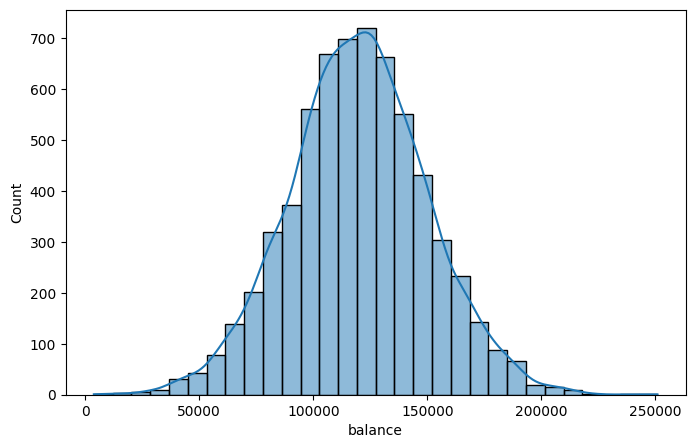

In [93]:
plt.figure(figsize=(8, 5))
sns.histplot(data=saving_customer_df, x='balance', bins=30, kde=True)
plt.show()

In [94]:
saving_customer_df.groupby('geography')['balance'].describe().T

geography,france,germany,spain
count,2596.000000,2508.000000,1277.000000
mean,119927.765597,119721.495993,119814.689577
std,31732.792620,27023.944318,32355.361987
min,3768.690000,27288.430000,12459.190000
25%,98440.985000,102796.830000,98052.660000
50%,120135.155000,119699.425000,119670.180000
75%,141143.112500,137499.442500,140355.600000
max,238387.560000,214346.960000,250898.090000


In [95]:
saving_customer_df.groupby('geography')['estimatedsalary'].describe().T

geography,france,germany,spain
count,2596.000000,2508.000000,1277.000000
mean,100625.034653,101113.804322,100127.278262
std,56941.502946,58274.627472,56576.974434
min,123.070000,11.580000,479.540000
25%,52575.295000,50982.392500,52341.150000
50%,100507.170000,102412.865000,101139.300000
75%,149563.020000,151099.517500,146738.830000
max,199929.170000,199970.740000,199953.330000


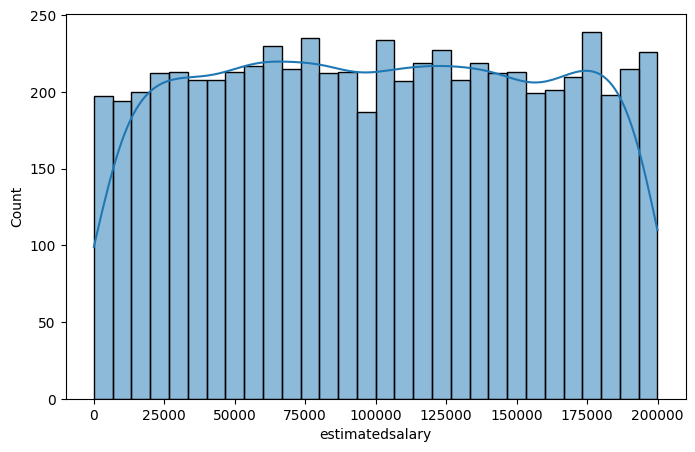

In [96]:
plt.figure(figsize=(8, 5))
sns.histplot(data=saving_customer_df, x='estimatedsalary', bins=30, kde=True)
plt.show()

In [97]:
saving_customer_df.groupby('geography')['creditscore'].describe().T

geography,france,germany,spain
count,2596.000000,2508.000000,1277.000000
mean,650.900231,651.484450,650.985904
std,97.141176,98.176324,94.142424
min,350.000000,350.000000,350.000000
25%,583.000000,584.000000,590.000000
50%,655.000000,651.000000,651.000000
75%,717.000000,722.250000,714.000000
max,850.000000,850.000000,850.000000


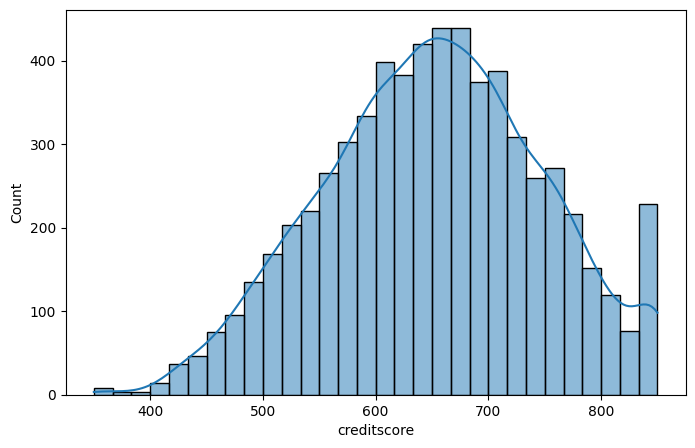

In [98]:
plt.figure(figsize=(8, 5))
sns.histplot(data=saving_customer_df, x='creditscore', bins=30, kde=True)
plt.show()

In [99]:
saving_customer_df['geography'].value_counts()

geography
france     2596
germany    2508
spain      1277
Name: count, dtype: Int64

In [100]:
saving_customer_df['gender'].value_counts()

gender
male      3493
female    2888
Name: count, dtype: Int64

In [101]:
saving_customer_df[(saving_customer_df['hascrcard'] == 0) & (saving_customer_df['exited'] == 0) &
                   (saving_customer_df['balance'] >= 100000) & (saving_customer_df['creditscore'] >= 700) &
                   (saving_customer_df['estimatedsalary'] >= 100000)].describe()

,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,age,estimatedsalary
count,243.000000,243.000000,243.0,243.000000,243.0,243.0,243.000000,243.000000,243.000000
mean,130852.710576,1.349794,0.0,5.045267,0.0,0.0,760.777778,36.094650,151929.929630
std,20663.477546,0.486459,0.0,2.818550,0.0,0.0,45.218569,7.638209,29394.290828
min,100054.770000,1.000000,0.0,0.000000,0.0,0.0,700.000000,18.000000,100137.700000
25%,115011.695000,1.000000,0.0,3.000000,0.0,0.0,722.000000,31.000000,125683.170000
50%,126875.620000,1.000000,0.0,5.000000,0.0,0.0,756.000000,36.000000,152039.670000
75%,144389.910000,2.000000,0.0,7.000000,0.0,0.0,788.000000,41.000000,177038.145000
max,191775.650000,3.000000,0.0,10.000000,0.0,0.0,850.000000,68.000000,199484.960000


The above dataframe is the same as potential_active_customers dataframe so we will just go with it.

In [102]:
pd.crosstab(potential_active_customers['geography'], potential_active_customers['gender'], rownames=['Has Credit Card'], colnames=['Churn Status'])

Churn Status,female,male
Has Credit Card,,
france,42,74
germany,50,37
spain,17,23


In [103]:
potential_active_customers['geography'].value_counts()

geography
france     116
germany     87
spain       40
Name: count, dtype: Int64

In [104]:
potential_active_customers['gender'].value_counts()

gender
male      134
female    109
Name: count, dtype: Int64

In [105]:
numerical_columns = saving_customer_df.select_dtypes(include=[float, int]).columns
numerical_columns

Index(['balance', 'numofproducts', 'hascrcard', 'tenure', 'isactivemember',
       'exited', 'creditscore', 'age', 'estimatedsalary'],
      dtype='object')

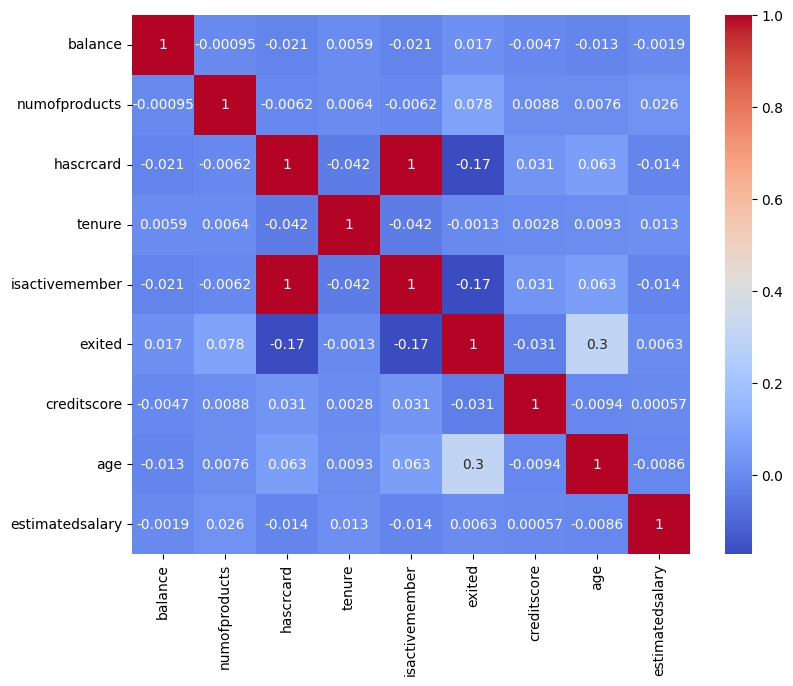

In [106]:
plt.figure(figsize=(9, 7))
sns.heatmap(saving_customer_df[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.show()

In [107]:
pd.crosstab(saving_customer_df['age_group'], saving_customer_df['exited'], rownames=['Age Group'], colnames=['Churn Status'], normalize='index') * 100

Churn Status,0,1
Age Group,,
18-20,94.339623,5.660377
21-23,88.965517,11.034483
24-31,90.396825,9.603175
32-44,81.671642,18.328358
45-60,45.768025,54.231975
above 60,69.360269,30.639731


In [108]:
saving_customer_df.groupby('exited')['balance'].describe().T

exited,0,1
count,4844.000000,1537.000000
mean,119531.225310,120746.971132
std,29949.467779,30555.192802
min,14262.800000,3768.690000
25%,99104.387500,103700.690000
50%,119786.615000,119948.090000
75%,139735.492500,137986.580000
max,221532.800000,250898.090000


Saving and income of churners are slightly more than non churners. For credit score and active rate, churners are lower than non churners. Customer duration is not relevant with churn. Age 40 to 60 customers are more likely to leave our bank. So marketing team should provide offer plan related with credit card and restrict loan plan to potential customers for 40 to 60 aged customers.

In [109]:
bank_customer_df.groupby('exited').describe().T.style.set_sticky()

In [110]:
churn_customer_df = bank_customer_df[bank_customer_df['exited'] == 1]
no_churn_customer_df = bank_customer_df[bank_customer_df['exited'] == 0]

In [111]:
bank_customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   balance                9997 non-null   float64 
 1   numofproducts          9997 non-null   int64   
 2   hascrcard              9997 non-null   int64   
 3   tenure                 9997 non-null   int64   
 4   isactivemember         9997 non-null   int64   
 5   exited                 9997 non-null   int64   
 6   creditscore            9997 non-null   int64   
 7   geography              9997 non-null   string  
 8   gender                 9997 non-null   string  
 9   age                    9997 non-null   int64   
 10  estimatedsalary        9997 non-null   float64 
 11  age_group              9997 non-null   category
 12  estimatedsalary_group  9997 non-null   category
dtypes: category(2), float64(2), int64(7), string(2)
memory usage: 957.3 KB


In [112]:
bank_customer_df['saving'] = (bank_customer_df['balance'] > 0).astype(int)
bank_customer_df['saving']

0        0
2        1
3        1
4        0
5        1
        ..
9996     0
9997     1
9998     0
9999     1
10000    1
Name: saving, Length: 9997, dtype: int64

According to statistical test and visual analysis, geography(germany) is the strongest influencer on churn rate. Inactive customers are more likely to churn than active customers.
We need to take care of providing credit card plan to improve engagement and reduce churn rate. Female customers are more likely to churn than male customers. Next, we continue to implement logistic regression for more accurate recommendations.

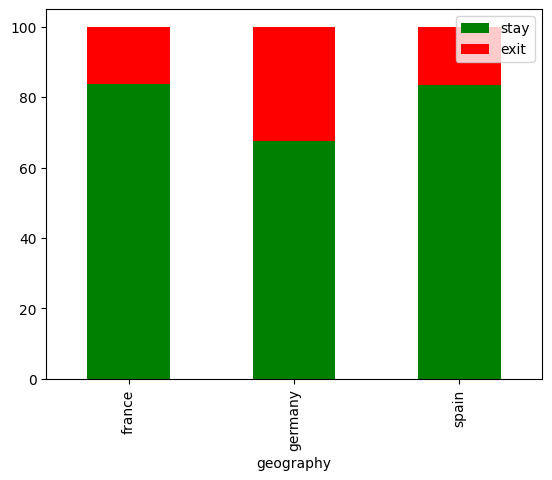

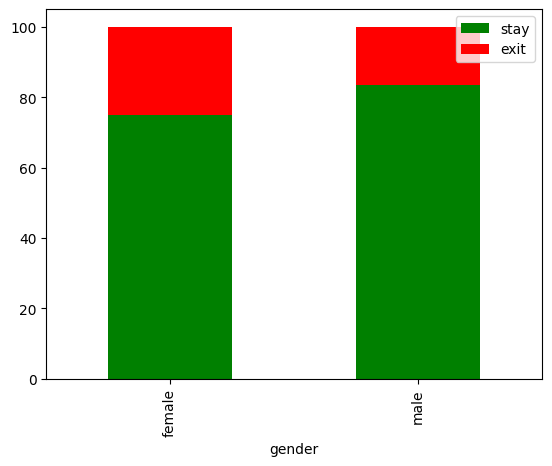

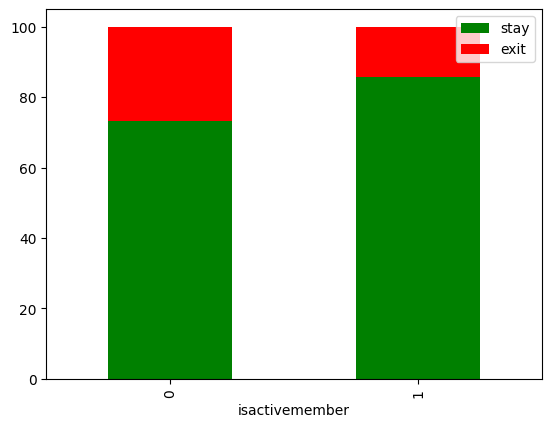

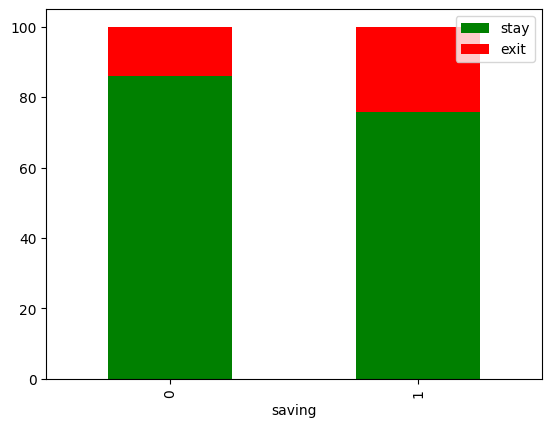

In [113]:
categorical_cols = ['geography', 'gender', 'isactivemember', 'saving']

for col in categorical_cols:
    ct = pd.crosstab(bank_customer_df[col], bank_customer_df['exited'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=['green', 'red'])
    plt.legend(loc='upper right', labels=['stay', 'exit'])
    plt.show()

In [114]:
contigency_table = {}
for col in categorical_cols:
    contigency_table[col] = pd.crosstab(bank_customer_df[col], bank_customer_df['exited'])
    display(contigency_table[col])

exited,0,1
geography,,
france,4203,810
germany,1694,814
spain,2063,413


exited,0,1
gender,,
female,3402,1139
male,4558,898


exited,0,1
isactivemember,,
0,3546,1302
1,4414,735


exited,0,1
saving,,
0,3116,500
1,4844,1537


In [115]:
from scipy.stats import chi2_contingency

chi2_results = []
for col in categorical_cols:
    chi2_stat, chi2_p_val, _, _ = chi2_contingency(contigency_table[col])
    chi2_results.append({'variable': col, 'p_value': chi2_p_val, 'statistic': chi2_stat})

chi2_results = pd.DataFrame(chi2_results)
chi2_results

,variable,p_value,statistic
0,geography,3.559626e-66,301.401921
1,gender,2.085494e-26,113.067532
2,isactivemember,9.360390e-55,242.859170
3,saving,2.708901e-34,149.113217


In [116]:
churn_group_tenure = churn_customer_df['tenure']
no_churn_group_tenure = no_churn_customer_df['tenure']

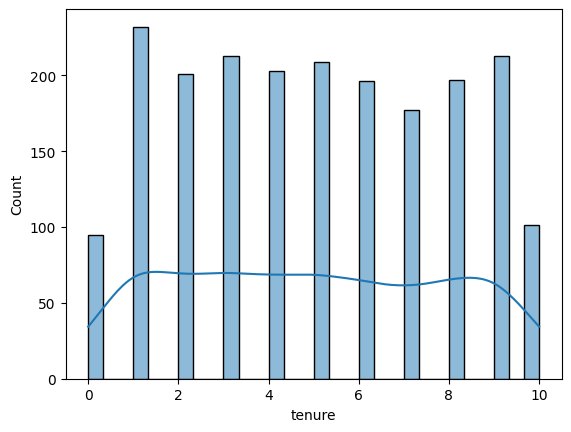

In [117]:
sns.histplot(churn_group_tenure, bins=30, kde=True)
plt.show()

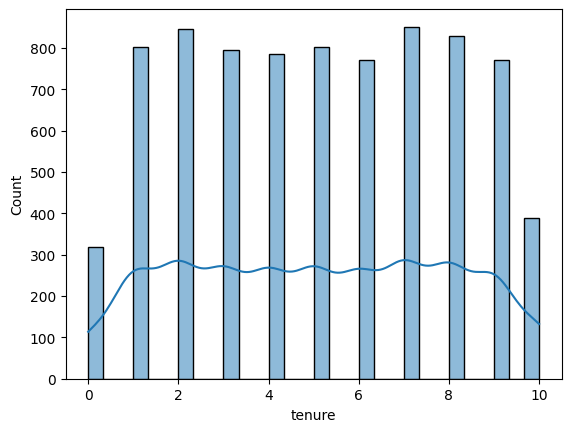

In [118]:
sns.histplot(no_churn_group_tenure, bins=30, kde=True)
plt.show()

In [119]:
from scipy.stats import mannwhitneyu
print(mannwhitneyu(churn_group_tenure, no_churn_group_tenure, alternative='two-sided'))

MannwhitneyuResult(statistic=np.float64(7944777.5), pvalue=np.float64(0.16013348514904724))


**There is significant difference in age between churners vs non-churners. Churners are likely to be older than non-churners.**

In [120]:
churn_group_age = churn_customer_df['age']
no_churn_group_age = no_churn_customer_df['age']

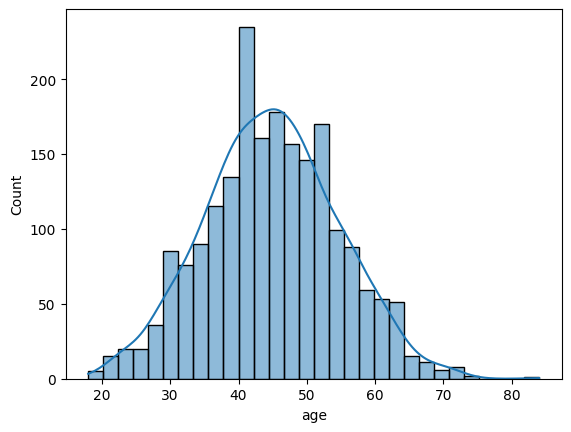

In [121]:
sns.histplot(churn_group_age, bins=30, kde=True)
plt.show()

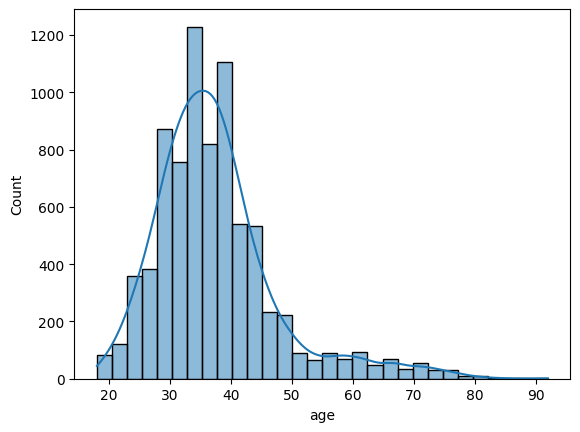

In [122]:
sns.histplot(no_churn_group_age, bins=30, kde=True)
plt.show()

In [123]:
(37.408166 - 36) / 37.408166

0.037643278208292844

In [124]:
from scipy.stats import levene
print(levene(churn_group_age, no_churn_group_age))

LeveneResult(statistic=np.float64(12.993575861412747), pvalue=np.float64(0.0003140822462859772))


In [125]:
from scipy.stats import ttest_ind
print(ttest_ind(churn_group_age, no_churn_group_age, equal_var=False))

TtestResult(statistic=np.float64(30.417889044303532), pvalue=np.float64(4.80213021198845e-179), df=np.float64(3248.894728555323))


## **Add to Streamlit**

**There is significant difference in num of products between churners vs non-churners. According to statistic sign, churners hold more products. Customers who hold more than 2 products are more likely to churn**

In [126]:
from scipy.stats import mannwhitneyu

churn_group_products = churn_customer_df['numofproducts']
no_churn_group_products = no_churn_customer_df['numofproducts']
print(mannwhitneyu(churn_group_products, no_churn_group_products, alternative='two-sided'))

MannwhitneyuResult(statistic=np.float64(6826628.0), pvalue=np.float64(4.463602918605092e-36))


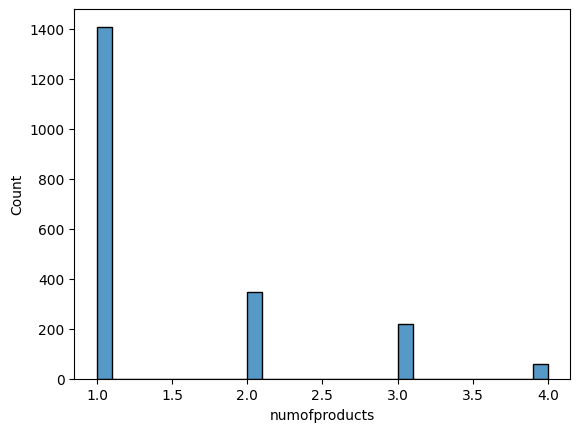

In [127]:
sns.histplot(churn_group_products, bins=30)
plt.show()

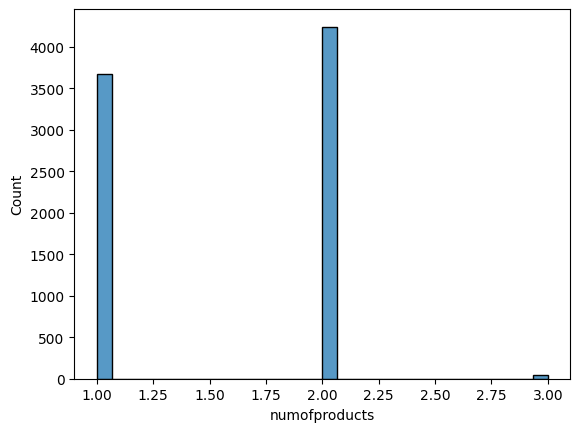

In [128]:
sns.histplot(no_churn_group_products, bins=30)
plt.show()

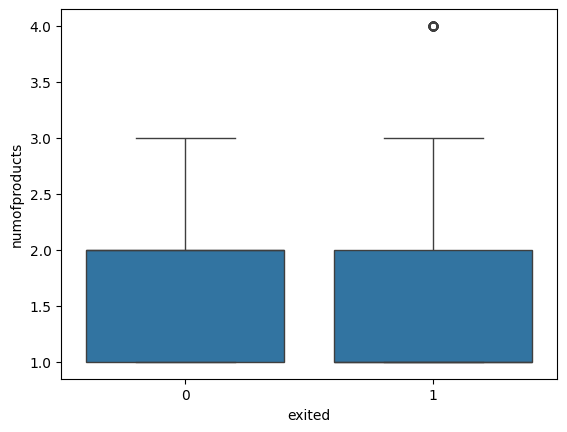

In [129]:
sns.boxplot(data=bank_customer_df, x='exited', y='numofproducts')
plt.show()

In [130]:
bank_customer_df.groupby('exited')['numofproducts'].describe().T

exited,0,1
count,7960.000000,2037.000000
mean,1.544472,1.475209
std,0.509522,0.801521
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,3.000000,4.000000


In [131]:
# pd.crosstab(bank_customer_df['exited'], bank_customer_df['numofproducts'], normalize='index') --> incorrect
pd.crosstab(bank_customer_df['numofproducts'], bank_customer_df['exited'], normalize='index')

exited,0,1
numofproducts,,
1,0.722692,0.277308
2,0.924183,0.075817
3,0.172932,0.827068
4,0.000000,1.000000


**According to Mann-Whitney U test result, there is no significant difference in income between churners vs non-churners.**

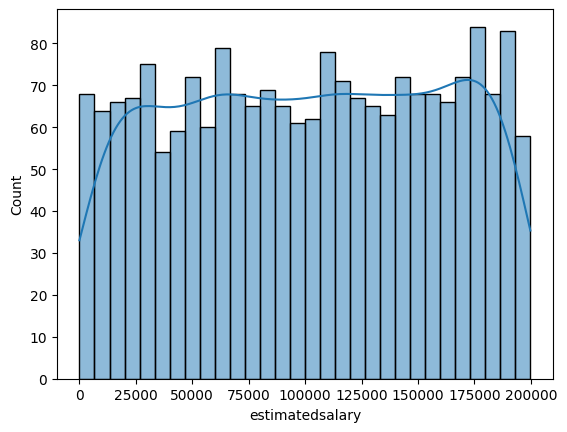

In [132]:
sns.histplot(data=churn_customer_df, x='estimatedsalary', bins=30, kde=True)
plt.show()

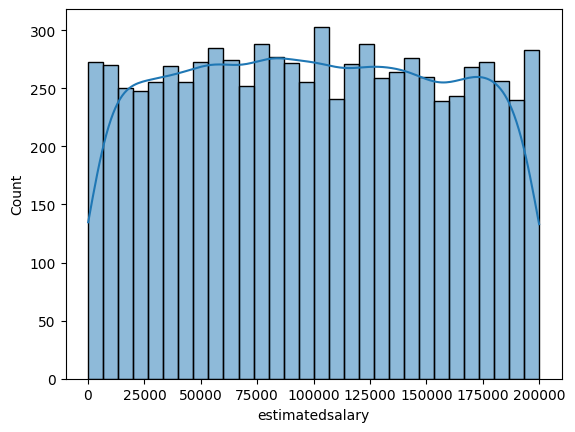

In [133]:
sns.histplot(data=no_churn_customer_df, x='estimatedsalary', bins=30, kde=True)
plt.show()

In [134]:
from scipy.stats import mannwhitneyu

churn_group_income = churn_customer_df['estimatedsalary']
no_churn_group_income = no_churn_customer_df['estimatedsalary']
mannwhitneyu_stat, p_val = mannwhitneyu(churn_group_income, no_churn_group_income, alternative='two-sided')
print(mannwhitneyu_stat, p_val)

8247444.0 0.22778365666167566


**There is significant difference in creditscore between churners vs non-churners. Churners have lower creditscore than non-churners.**

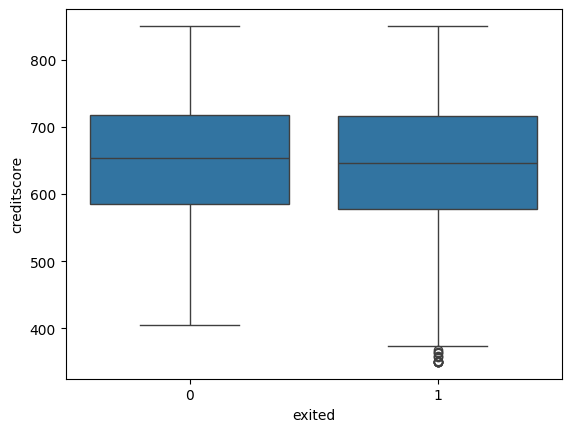

In [135]:
sns.boxplot(data=bank_customer_df, x='exited', y='creditscore')
plt.show()

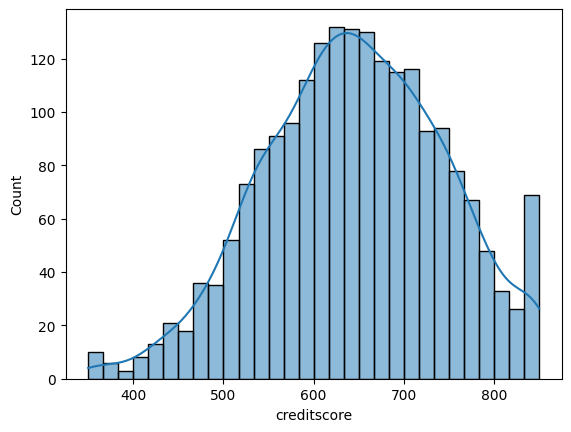

In [136]:
sns.histplot(data=churn_customer_df, x='creditscore', bins=30, kde=True)
plt.show()

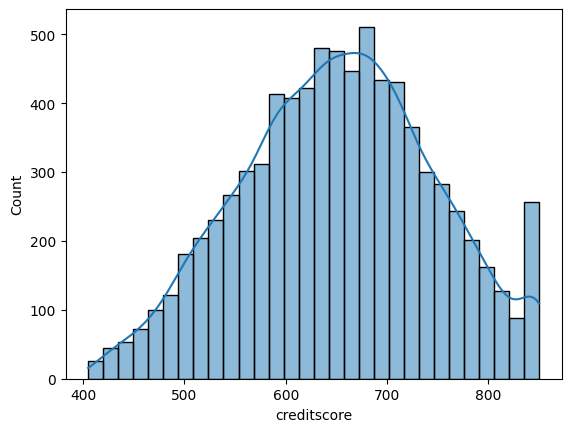

In [137]:
sns.histplot(data=no_churn_customer_df, x='creditscore', bins=30, kde=True)
plt.show()

In [138]:
print((653 - 651.874497) / 653)    # non-churners
print((646 - 645.351497) / 646)    # churners

0.0017235880551301388
0.0010038746130031039


In [139]:
churn_group_credit_score = churn_customer_df['creditscore']
no_churn_group_credit_score = no_churn_customer_df['creditscore']
print(levene(churn_group_credit_score, no_churn_group_credit_score))

LeveneResult(statistic=np.float64(5.509894925242024), pvalue=np.float64(0.01892858531190648))


In [140]:
print(ttest_ind(churn_group_credit_score, no_churn_group_credit_score, equal_var=False))

TtestResult(statistic=np.float64(-2.6431713142700652), pvalue=np.float64(0.008255348159983402), df=np.float64(3051.39873579452))


**According to t-test result, saving does not impact churn.**

In [141]:
saving_churn_customer_df = saving_customer_df[saving_customer_df['exited'] == 1]
saving_no_churn_customer_df = saving_customer_df[saving_customer_df['exited'] == 0]

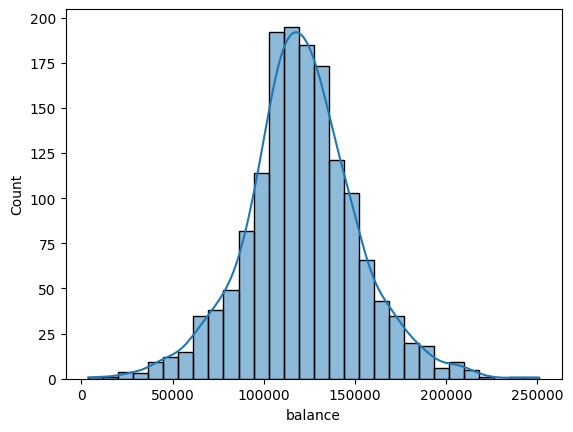

In [142]:
sns.histplot(data=saving_churn_customer_df, x='balance', bins=30, kde=True)
plt.show()

In [143]:
(120746.971132 - 119948.090000) / 120746.971132

0.006616158769951062

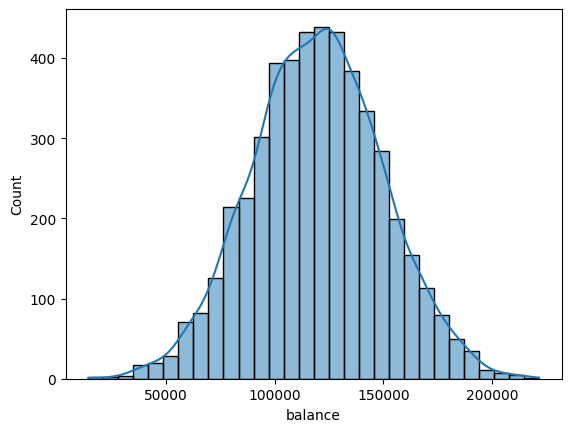

In [144]:
sns.histplot(data=saving_no_churn_customer_df, x='balance', bins=30, kde=True)
plt.show()

In [145]:
(119786.615000 - 119531.225310) / 119531.225310

0.00213659392629555

In [146]:
from scipy.stats import levene

saving_churn_group_balance = saving_churn_customer_df['balance']
saving_no_churn_group_balance = saving_no_churn_customer_df['balance']
leven_stat, p_value = levene(saving_churn_group_balance, saving_no_churn_group_balance)
print(leven_stat, p_value)

2.945753863336243 0.08615206557576828


In [147]:
from scipy.stats import ttest_ind
ttest_stat, p_value = ttest_ind(saving_churn_group_balance, saving_no_churn_group_balance)
print(ttest_stat, p_value)

1.3798197713690539 0.1676905036866935


In [148]:
bank_customer_df.columns

Index(['balance', 'numofproducts', 'hascrcard', 'tenure', 'isactivemember',
       'exited', 'creditscore', 'geography', 'gender', 'age',
       'estimatedsalary', 'age_group', 'estimatedsalary_group', 'saving'],
      dtype='object')

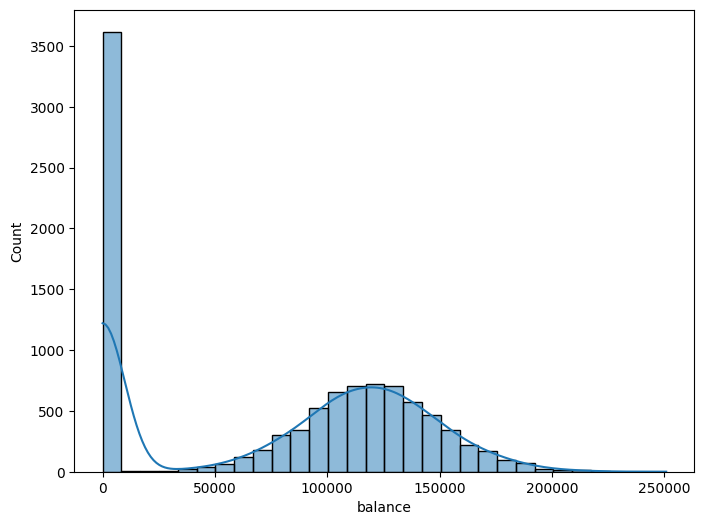

In [149]:
plt.figure(figsize=(8, 6))
sns.histplot(data=bank_customer_df, x='balance', bins=30, kde=True)
plt.show()

In [150]:
bank_customer_df['saving_group'] = pd.cut(bank_customer_df['balance'], bins=[-1, 0, 50000, 100000, 150000, 200000, 300000], 
                                          labels=['no saving', 'below 50k', '50k - 100k', '100k - 150k', '150k - 200k', 'above 200k'])

In [151]:
bank_customer_df['saving_group'].value_counts(normalize=True)

saving_group
100k - 150k    0.382915
no saving      0.361709
50k - 100k     0.150945
150k - 200k    0.093528
below 50k      0.007502
above 200k     0.003401
Name: proportion, dtype: float64

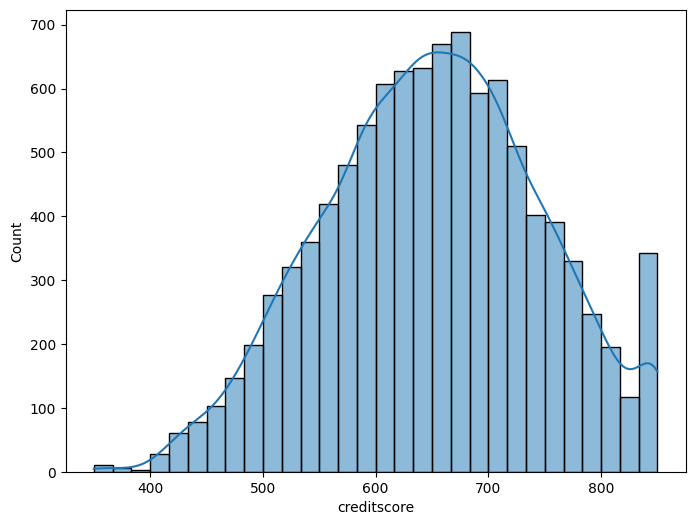

In [152]:
plt.figure(figsize=(8, 6))
sns.histplot(data=bank_customer_df, x='creditscore', bins=30, kde=True)
plt.show()

In [153]:
bank_customer_df['creditscore_group'] = pd.cut(bank_customer_df['creditscore'], bins=[0, 650, 700, 850], labels=['below 650', '650 - 700', 'above 700'])

In [154]:
bank_customer_df['creditscore_group'].value_counts(normalize=True)

creditscore_group
below 650    0.493648
above 700    0.311694
650 - 700    0.194658
Name: proportion, dtype: float64

In [155]:
bank_customer_df.columns

Index(['balance', 'numofproducts', 'hascrcard', 'tenure', 'isactivemember',
       'exited', 'creditscore', 'geography', 'gender', 'age',
       'estimatedsalary', 'age_group', 'estimatedsalary_group', 'saving',
       'saving_group', 'creditscore_group'],
      dtype='object')

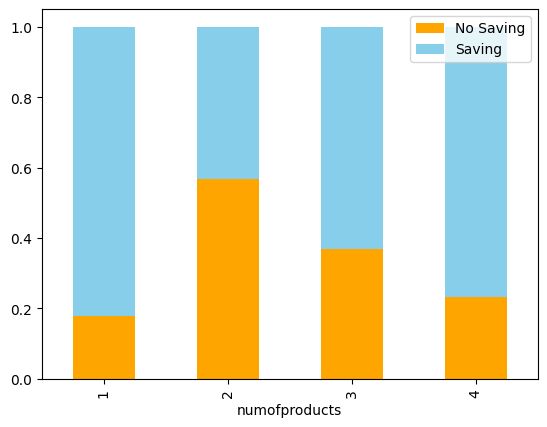

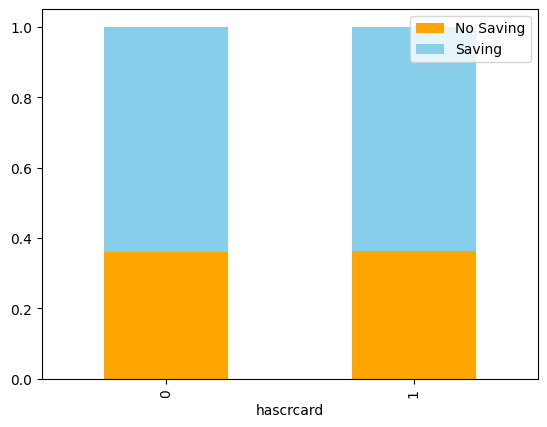

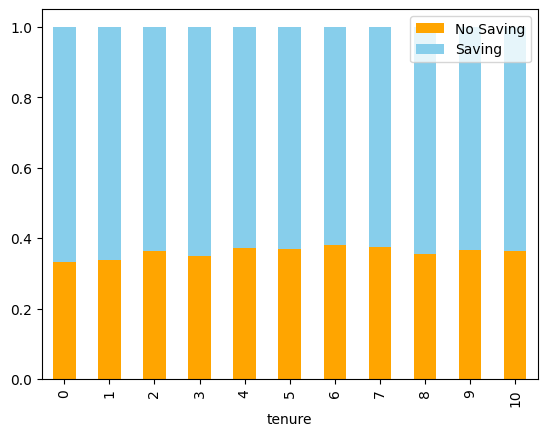

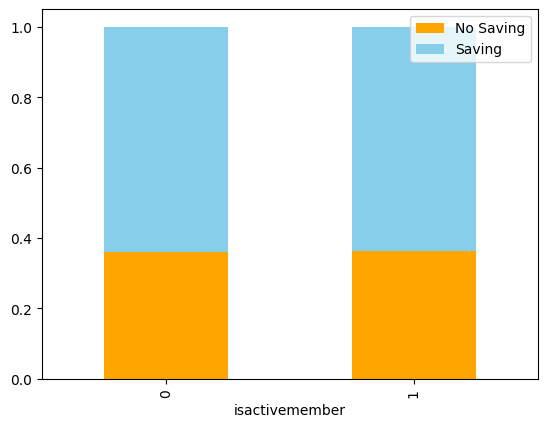

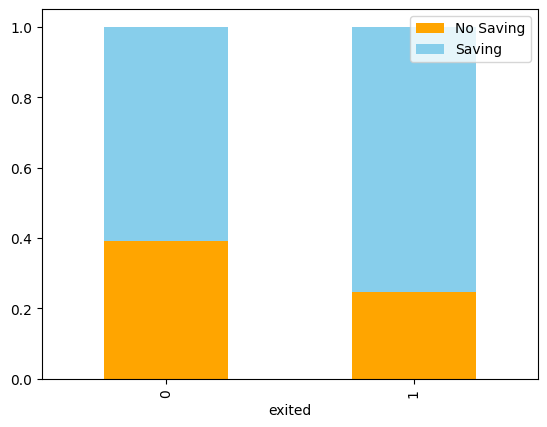

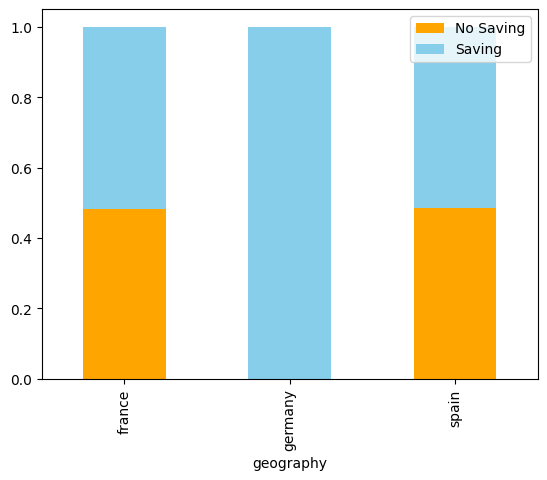

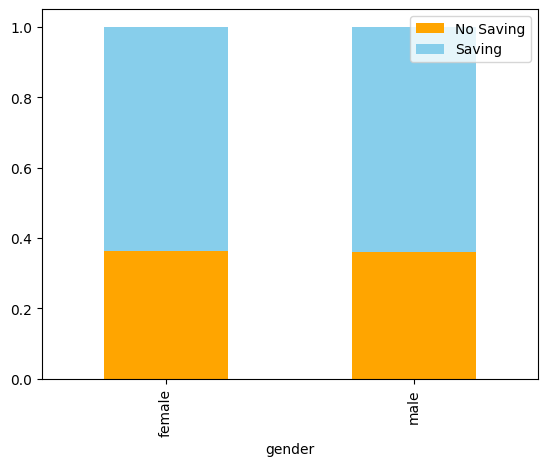

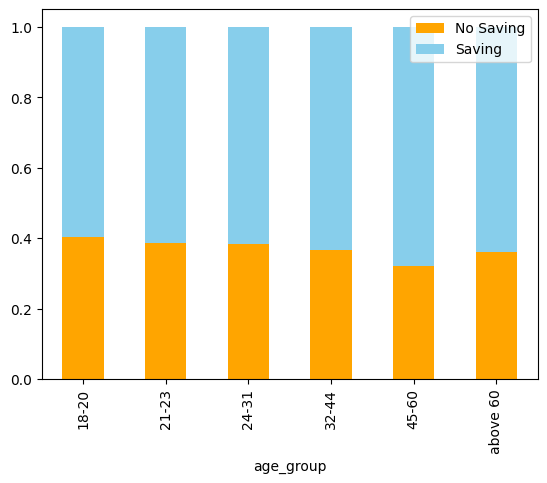

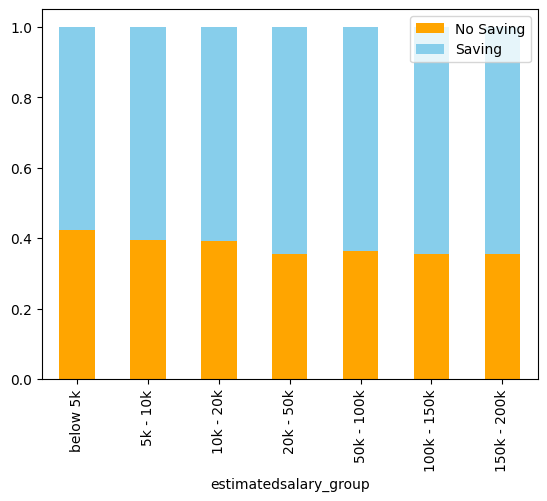

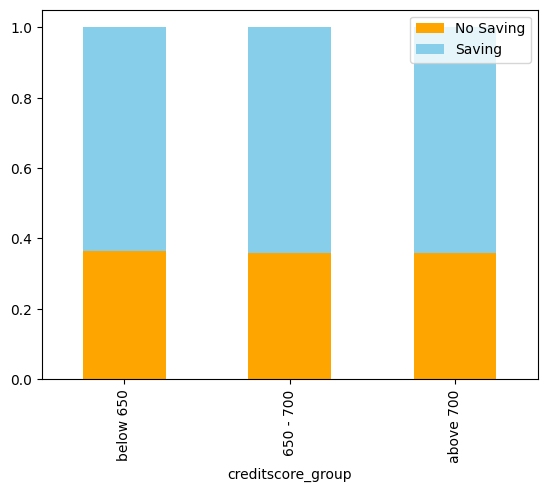

In [156]:
saving_categorical_columns = ['numofproducts', 'hascrcard', 'tenure', 'isactivemember',
       'exited', 'geography', 'gender', 'age_group', 'estimatedsalary_group', 'creditscore_group']
for col in saving_categorical_columns:
    ct = pd.crosstab(bank_customer_df[col], bank_customer_df['saving'], normalize='index')
    ct.plot(kind='bar', stacked=True, color=['orange', 'skyblue'])
    plt.legend(loc='upper right', labels=['No Saving', 'Saving'])
    plt.show()

About 48 percent of france and spain customers are no saving customers and all germany customers are saving customers.

In [157]:
pd.crosstab(no_saving_customer_df['geography'], no_saving_customer_df['gender'], rownames=['Geography'], colnames=['Gender'])

Gender,female,male
Geography,,
france,1108,1309
spain,545,654


In [158]:
saving_customer_df.groupby('geography').describe().T.style.set_sticky()

Germany customers have higher churn rate than other countries. They have higher income, higher number of products, but less active rate than other countries. We need to run regression tests to evaluate which factors influence more on churn rate

In [159]:
scale_columns = ['numofproducts', 'age', 'creditscore', 'estimatedsalary', 'balance']

In [160]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
for col in scale_columns:
    bank_customer_df[col + '_scale'] = scaler.fit_transform(bank_customer_df[[col]])

In [161]:
bank_customer_df['numofproducts_scale'].unique()

array([0.        , 0.66666667, 0.33333333, 1.        ])

In [162]:
bank_customer_df['gender_scale'] = bank_customer_df['gender'].map({'male': 0, 'female': 1}).astype(int)

In [163]:
geography_dummies = pd.get_dummies(bank_customer_df['geography'], prefix='geography', drop_first=True).astype(int)
saving_group_dummies = pd.get_dummies(bank_customer_df['saving_group'], prefix='saving_group', drop_first=True).astype(int)
creditscore_group_dummies = pd.get_dummies(bank_customer_df['creditscore_group'], prefix='creditscore_group', drop_first=True).astype(int)
age_group_dummies = pd.get_dummies(bank_customer_df['age_group'], prefix='age_group', drop_first=True).astype(int)
salary_group_dummies = pd.get_dummies(bank_customer_df['estimatedsalary_group'], prefix='salary_group', drop_first=True).astype(int)
numofproducts_dummies = pd.get_dummies(bank_customer_df['numofproducts'], prefix='numofproducts', drop_first=True).astype(int)

In [164]:
bank_customer_df = pd.concat([bank_customer_df, geography_dummies, saving_group_dummies, creditscore_group_dummies,
                              age_group_dummies, salary_group_dummies, numofproducts_dummies], axis=1)

In [165]:
bank_customer_df.columns

Index(['balance', 'numofproducts', 'hascrcard', 'tenure', 'isactivemember',
       'exited', 'creditscore', 'geography', 'gender', 'age',
       'estimatedsalary', 'age_group', 'estimatedsalary_group', 'saving',
       'saving_group', 'creditscore_group', 'numofproducts_scale', 'age_scale',
       'creditscore_scale', 'estimatedsalary_scale', 'balance_scale',
       'gender_scale', 'geography_germany', 'geography_spain',
       'saving_group_below 50k', 'saving_group_50k - 100k',
       'saving_group_100k - 150k', 'saving_group_150k - 200k',
       'saving_group_above 200k', 'creditscore_group_650 - 700',
       'creditscore_group_above 700', 'age_group_21-23', 'age_group_24-31',
       'age_group_32-44', 'age_group_45-60', 'age_group_above 60',
       'salary_group_5k - 10k', 'salary_group_10k - 20k',
       'salary_group_20k - 50k', 'salary_group_50k - 100k',
       'salary_group_100k - 150k', 'salary_group_150k - 200k',
       'numofproducts_2', 'numofproducts_3', 'numofproducts_4']

In [166]:
# Checking for duplicate columns
bank_customer_df.columns[bank_customer_df.columns.duplicated()]

Index([], dtype='object')

In [167]:
X = bank_customer_df.drop(columns=['exited', 'geography', 'gender', 'age_group', 'estimatedsalary_group', 'saving_group', 'creditscore_group', 
                                   'isactivemember', 'balance', 'creditscore', 'age', 'numofproducts', 'estimatedsalary', 'balance',
                                   'numofproducts_scale', 'age_scale', 'creditscore_scale', 'estimatedsalary_scale', 'balance_scale'])
y = bank_customer_df['exited']

In [168]:
X.dtypes

hascrcard                      int64
tenure                         int64
saving                         int64
gender_scale                   int64
geography_germany              int64
geography_spain                int64
saving_group_below 50k         int64
saving_group_50k - 100k        int64
saving_group_100k - 150k       int64
saving_group_150k - 200k       int64
saving_group_above 200k        int64
creditscore_group_650 - 700    int64
creditscore_group_above 700    int64
age_group_21-23                int64
age_group_24-31                int64
age_group_32-44                int64
age_group_45-60                int64
age_group_above 60             int64
salary_group_5k - 10k          int64
salary_group_10k - 20k         int64
salary_group_20k - 50k         int64
salary_group_50k - 100k        int64
salary_group_100k - 150k       int64
salary_group_150k - 200k       int64
numofproducts_2                int64
numofproducts_3                int64
numofproducts_4                int64
d

In [169]:
X.columns[X.columns.duplicated()]

Index([], dtype='object')

In [170]:
X.describe()

,hascrcard,tenure,saving,gender_scale,geography_germany,geography_spain,saving_group_below 50k,saving_group_50k - 100k,saving_group_100k - 150k,saving_group_150k - 200k,...,age_group_above 60,salary_group_5k - 10k,salary_group_10k - 20k,salary_group_20k - 50k,salary_group_50k - 100k,salary_group_100k - 150k,salary_group_150k - 200k,numofproducts_2,numofproducts_3,numofproducts_4
count,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,...,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000,9997.000000
mean,0.515055,5.013204,0.638291,0.454236,0.250875,0.247674,0.007502,0.150945,0.382915,0.093528,...,0.046414,0.024407,0.047814,0.146744,0.253676,0.255377,0.245574,0.459138,0.026608,0.006002
std,0.499798,2.892364,0.480519,0.497926,0.433539,0.431683,0.086294,0.358013,0.486122,0.291186,...,0.210390,0.154318,0.213384,0.353868,0.435136,0.436095,0.430448,0.498352,0.160943,0.077242
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,7.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [171]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [172]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7997, 27)
(2000, 27)
(7997,)
(2000,)


### **Logistic Regression Result**

In [173]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=200)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


LR Accuray Score: 0.7875


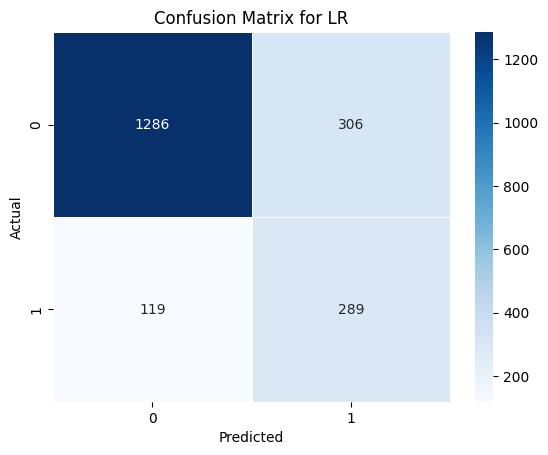

LR Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86      1592
           1       0.49      0.71      0.58       408

    accuracy                           0.79      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.83      0.79      0.80      2000



In [174]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_lr = lr.predict(X_test)
print("LR Accuray Score: {}".format(accuracy_score(y_test, y_pred_lr)))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for LR')
plt.show()

print("LR Classification Report:\n",classification_report(y_test, y_pred_lr))

In [175]:
logistic_features = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
}).sort_values(by='coefficient', ascending=False)
logistic_features.to_csv(f"{folder}/feature_coefficient.csv")

### **Random Forest Classifier + RandomizedSearchCV Result**

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Training score: 0.858
Best parameters set:
 {'clf__n_estimators': 200, 'clf__min_samples_split': 3, 'clf__min_samples_leaf': 1, 'clf__max_depth': 10}
RFC Accuracy score: 0.857


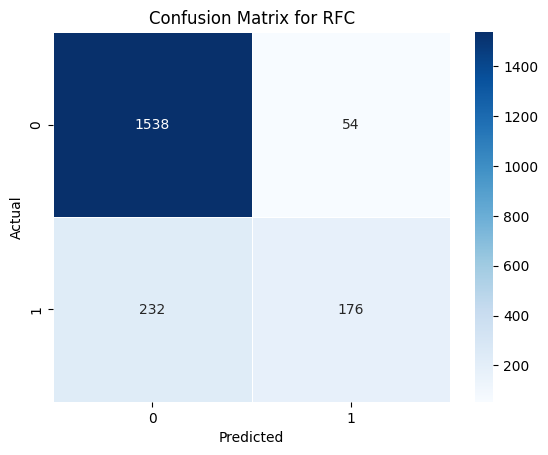

RFC Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.91      1592
           1       0.77      0.43      0.55       408

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



In [176]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

pipeline_rfc = Pipeline([('clf', RandomForestClassifier(criterion='gini'))])
parameters_rfc = {
    'clf__n_estimators': (200, 300, 400, 500),
    'clf__max_depth': (5, 10, 15, 20),
    'clf__min_samples_split': (2, 3, 4, 5),
    'clf__min_samples_leaf': (1, 2, 3, 4)}
random_search_rfc = RandomizedSearchCV(pipeline_rfc, parameters_rfc, n_iter=20, cv=5, n_jobs=-1, verbose=1, scoring='roc_auc', random_state=42)
random_search_rfc.fit(X_train, y_train)
print ('Best Training score: %0.3f' % random_search_rfc.best_score_)
print ('Best parameters set:\n', random_search_rfc.best_params_)

y_pred_rfc = random_search_rfc.predict(X_test)

print("RFC Accuracy score: {}".format(accuracy_score(y_test, y_pred_rfc)))

cm_rfc = confusion_matrix(y_test, y_pred_rfc)
sns.heatmap(cm_rfc, cmap='Blues', annot=True, linewidths=0.5, fmt='.0f')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for RFC')
plt.show()

print("RFC Classification Report:\n",classification_report(y_test, y_pred_rfc))

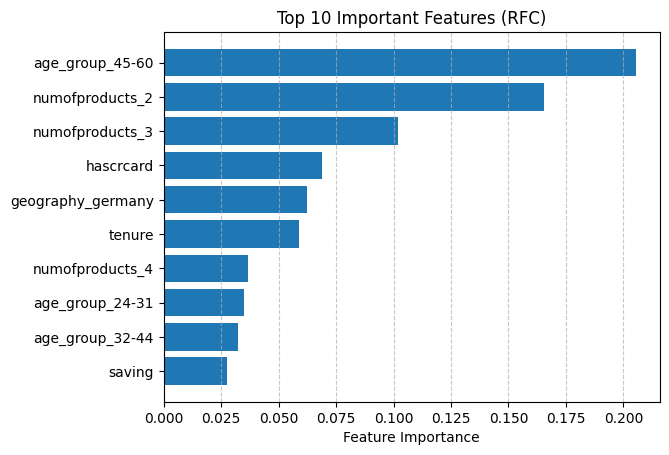

In [177]:
best_rfc = random_search_rfc.best_estimator_[0]
rfc_importances = best_rfc.feature_importances_
features = X_train.columns
indices = np.argsort(rfc_importances)[::-1][:10]
top_features = features[indices].values
top_values = rfc_importances[indices]

fig, ax = plt.subplots()
ax.barh(top_features, top_values, align='center')
ax.yaxis.set_inverted(True)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Important Features (RFC)')
plt.grid(axis='x', ls='--', alpha=0.7)
plt.show()

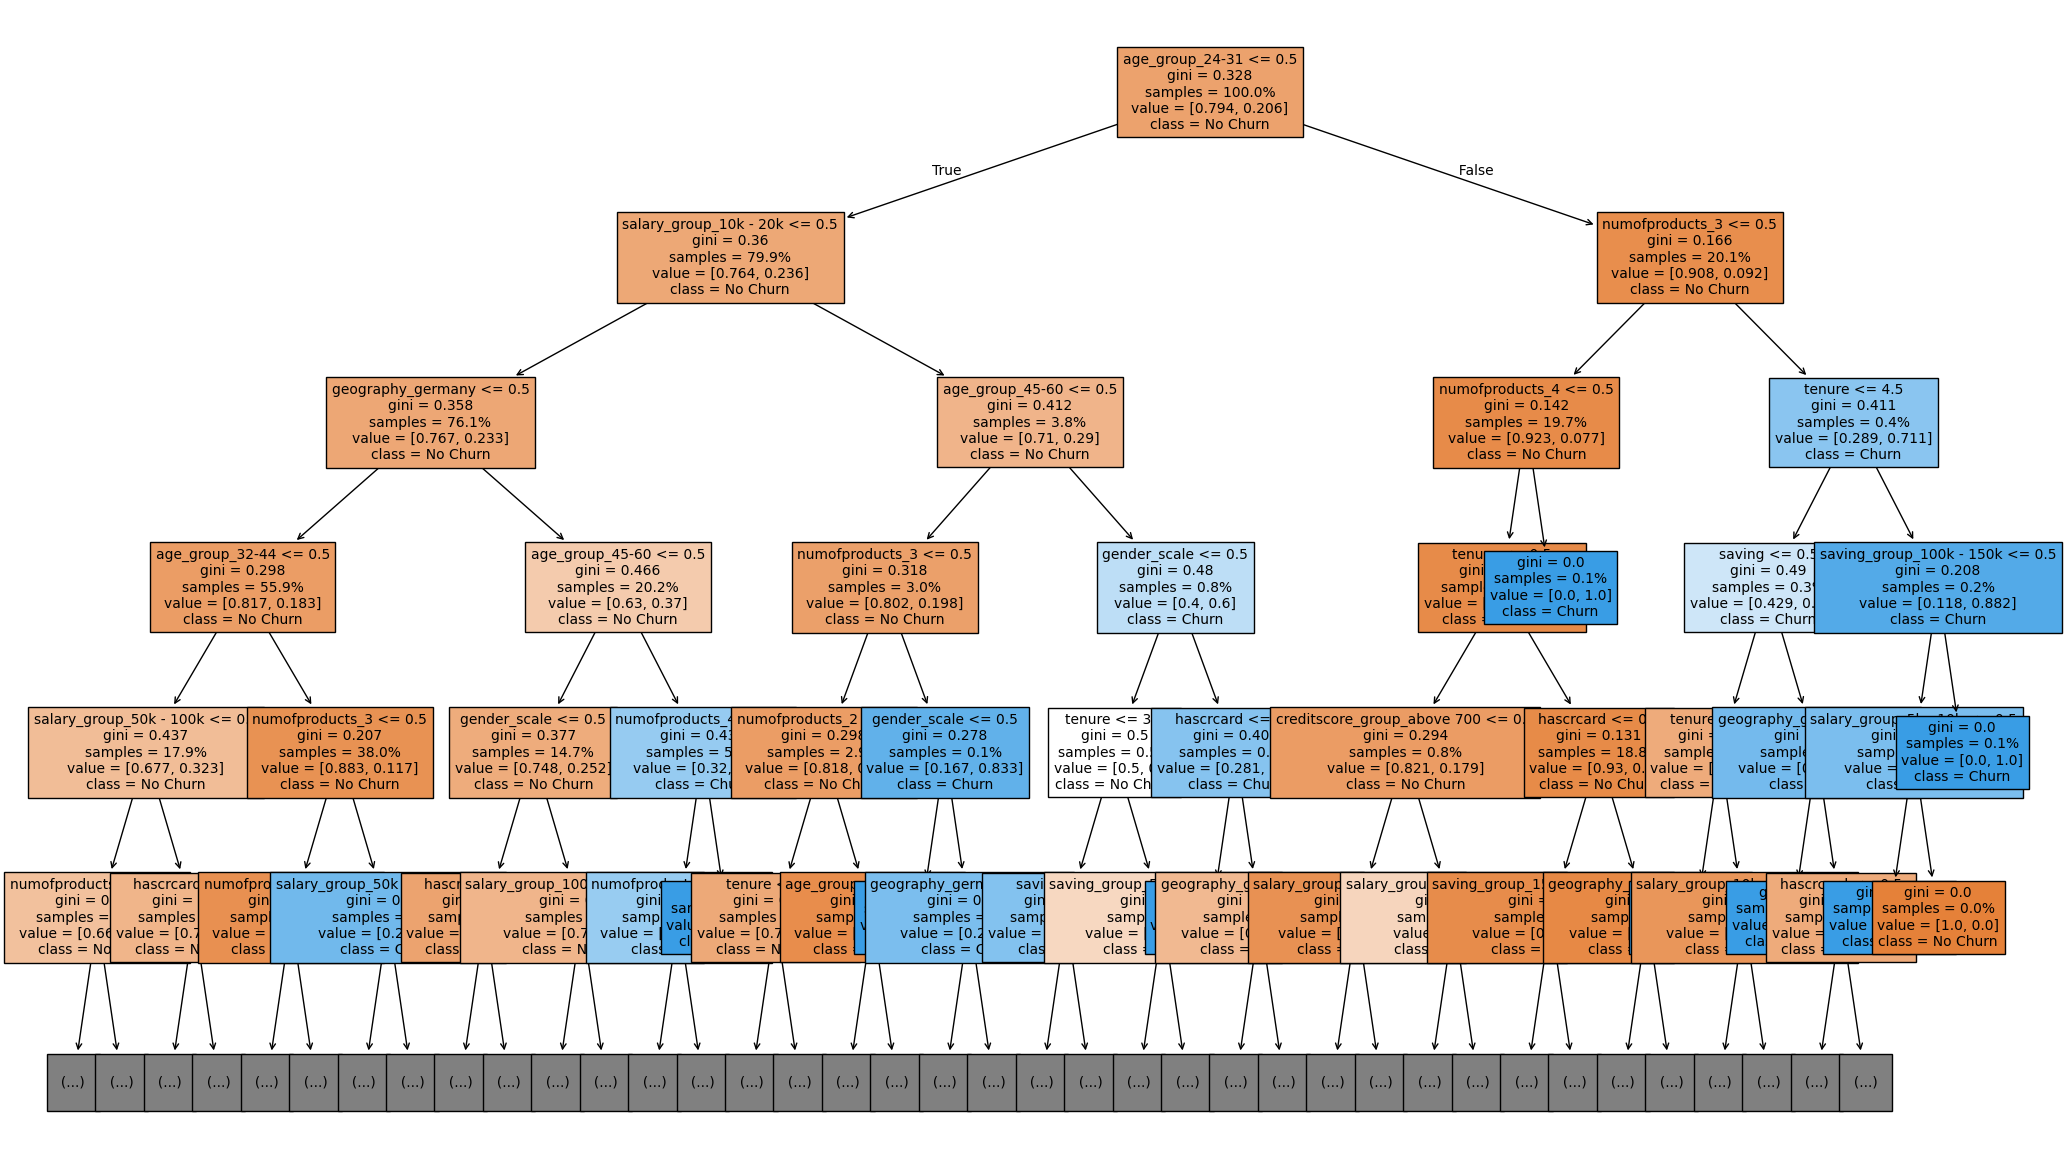

In [178]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25, 15))
plot_tree(best_rfc.estimators_[0], feature_names=X.columns, class_names=['No Churn', 'Churn'], 
          max_depth=5, filled=True, fontsize=10, impurity=True, proportion=True)
plt.show()

### **XGBoost Classifer + RandomizedSearchCV Result**

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Training score: 0.857
Best parameters set:
 {'clf__n_estimators': 300, 'clf__max_depth': 10, 'clf__learning_rate': 0.03, 'clf__gamma': 3}
XGBC Accuracy score: 0.8565


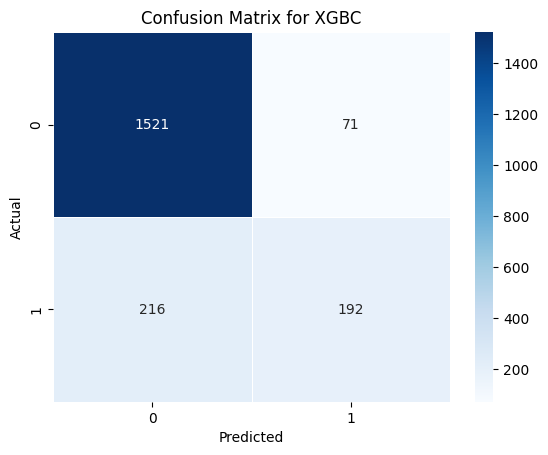

XGBC Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.91      1592
           1       0.73      0.47      0.57       408

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [179]:
from xgboost import XGBClassifier
pipeline_xgbc = Pipeline([('clf', XGBClassifier(random_state=42, eval_metric='logloss'))])
parameters_xgbc = {
    'clf__n_estimators': (200, 300, 400, 500),
    'clf__max_depth': (5, 7, 10, 15),
    'clf__gamma': (0, 1, 2, 3),
    'clf__learning_rate': (0.01, 0.03, 0.05, 0.06)}
random_search_xgbc = RandomizedSearchCV(pipeline_xgbc, parameters_xgbc, n_iter=20, cv=5, n_jobs=-1, verbose=1, scoring='roc_auc', random_state=42)
random_search_xgbc.fit(X_train, y_train)
print ('Best Training score: %0.3f' % random_search_xgbc.best_score_)
print ('Best parameters set:\n',random_search_xgbc.best_params_)

y_pred_xgb = random_search_xgbc.predict(X_test)

print("XGBC Accuracy score: {}".format(accuracy_score(y_test, y_pred_xgb)))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, cmap='Blues', annot=True, linewidths=0.5, fmt='.0f')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for XGBC')
plt.show()

print("XGBC Classification Report:\n",classification_report(y_test, y_pred_xgb))

/Users/eziokenway/.local/share/virtualenvs/Bank_Churn_Customer-MwIQ3wfh/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 99%|===================| 7907/7997 [00:40<00:00]        

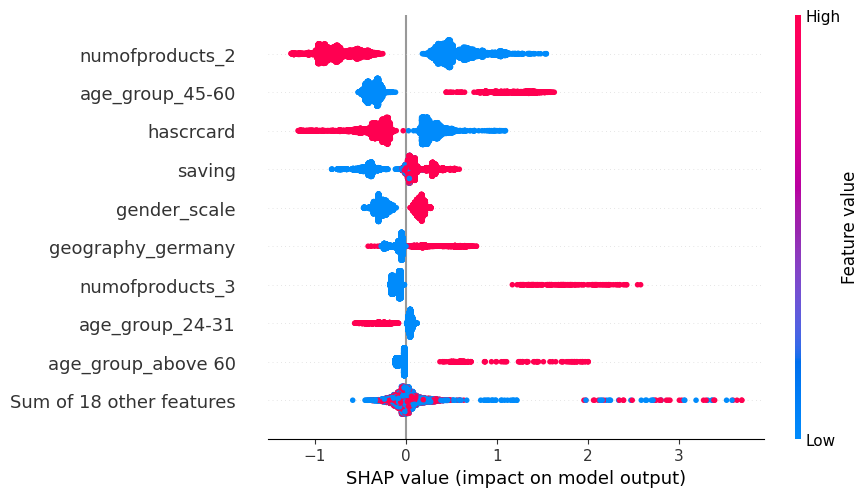

In [180]:
import shap

best_xgbc = random_search_xgbc.best_estimator_[0]
explainer = shap.Explainer(best_xgbc, X_train)
shap_values = explainer(X_train)

shap.plots.beeswarm(shap_values)

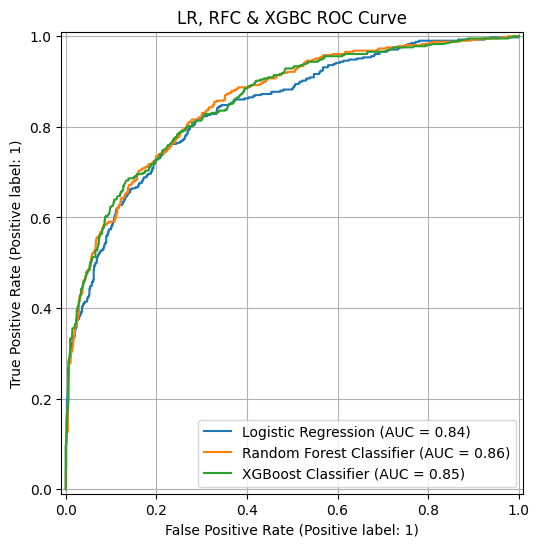

In [181]:
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(best_rfc, X_test, y_test, ax=ax, name='Random Forest Classifier')
RocCurveDisplay.from_estimator(best_xgbc, X_test, y_test, ax=ax, name='XGBoost Classifier')
plt.title('LR, RFC & XGBC ROC Curve')
plt.grid(True)
plt.show()

**XGBoost Classifier has the best f1 score for No-Churn(0.91) and Churn(0.57) combined. We will choose it for computing the probabilites of No-Churn and Churn respectively**

In [182]:
no_churn_proba = best_xgbc.predict_proba(X)[:, 0]
churn_proba = best_xgbc.predict_proba(X)[:, 1]
predicted = best_xgbc.predict(X)

In [191]:
bank_customer_df['no_churn_proba'] = no_churn_proba
bank_customer_df['churn_proba'] = churn_proba
bank_customer_df['predicted'] = predicted
bank_customer_df['customerid'] = customerid_col
bank_customer_df['surname'] = surname_col
bank_customer_df = bank_customer_df[['customerid', 'surname', 'balance', 'numofproducts', 'hascrcard', 'tenure', 'isactivemember',
       'exited', 'creditscore', 'geography', 'gender', 'age',
       'estimatedsalary', 'age_group', 'estimatedsalary_group', 'saving',
       'saving_group', 'creditscore_group', 'numofproducts_scale', 'age_scale',
       'creditscore_scale', 'estimatedsalary_scale', 'balance_scale',
       'gender_scale', 'geography_germany', 'geography_spain',
       'saving_group_below 50k', 'saving_group_50k - 100k',
       'saving_group_100k - 150k', 'saving_group_150k - 200k',
       'saving_group_above 200k', 'creditscore_group_650 - 700',
       'creditscore_group_above 700', 'age_group_21-23', 'age_group_24-31',
       'age_group_32-44', 'age_group_45-60', 'age_group_above 60',
       'salary_group_5k - 10k', 'salary_group_10k - 20k',
       'salary_group_20k - 50k', 'salary_group_50k - 100k',
       'salary_group_100k - 150k', 'salary_group_150k - 200k',
       'numofproducts_2', 'numofproducts_3', 'numofproducts_4',
       'no_churn_proba', 'churn_proba', 'predicted']]

bank_customer_df.to_csv(f"{folder}/cleaned_data.csv")

In [192]:
bank_customer_df

,customerid,surname,balance,numofproducts,hascrcard,tenure,isactivemember,exited,creditscore,geography,...,salary_group_20k - 50k,salary_group_50k - 100k,salary_group_100k - 150k,salary_group_150k - 200k,numofproducts_2,numofproducts_3,numofproducts_4,no_churn_proba,churn_proba,predicted
0,15634602,Hargrave,0.00,1,1,2,1,1,619,france,...,0,0,1,0,0,0,0,0.713470,0.286530,0
2,15647311,Hill,83807.86,1,1,1,1,0,608,spain,...,0,0,1,0,0,0,0,0.813168,0.186832,0
3,15619304,Onio,159660.80,3,0,8,0,1,502,france,...,0,0,1,0,0,1,0,0.141772,0.858228,1
4,15701354,Boni,0.00,2,0,1,0,0,699,france,...,0,1,0,0,1,0,0,0.946501,0.053499,0
5,15737888,Mitchell,125510.82,1,1,2,1,0,850,spain,...,0,1,0,0,0,0,0,0.898722,0.101278,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,15606229,Obijiaku,0.00,2,0,5,0,0,771,france,...,0,1,0,0,1,0,0,0.968677,0.031323,0
9997,15569892,Johnstone,57369.61,1,1,10,1,0,516,france,...,0,0,1,0,0,0,0,0.930425,0.069575,0
9998,15584532,Liu,0.00,1,1,7,1,1,709,france,...,1,0,0,0,0,0,0,0.850980,0.149020,0
9999,15682355,Sabbatini,75075.31,2,0,3,0,1,772,germany,...,0,1,0,0,1,0,0,0.917975,0.082025,0
